In [1]:
!rm -rf /kaggle/working/

rm: cannot remove '/kaggle/working/': Device or resource busy


In [2]:
import os
import sys
import logging
import warnings
from PIL import Image

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*can only test a child process.*")
warnings.filterwarnings("ignore", message=".*Exception ignored in.*")
warnings.filterwarnings("ignore", message=".*_MultiProcessingDataLoaderIter.*")
warnings.filterwarnings("ignore", message=".*_shutdown_workers.*")

logging.disable(logging.CRITICAL)

os.environ["PYTHONWARNINGS"] = "ignore"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

Image.MAX_IMAGE_PIXELS = None

class SuppressOutput:
    def write(self, x):
        pass

    def flush(self):
        pass

sys.stderr = SuppressOutput()

In [3]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import os
import random
import numpy as np
import torch
import pandas as pd
from IPython.display import clear_output
import seaborn as sns
import os
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torchvision import models
import torch
import torch.nn as nn
from tqdm.notebook import tqdm
from tabulate import tabulate
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary

%matplotlib inline

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Seed: {SEED}")
print(f"Device: {DEVICE}")

Seed: 42
Device: cuda


In [5]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

In [6]:
DATA_ROOT      = "/kaggle/input/datasets/evilspirit05/ecg-analysis/ecg_data"
IMAGE_SIZE     = 224
BATCH_SIZE     = 4
EPOCHS         = 50
LEARNING_RATE  = 3e-5
RANDOM_SEED    = 42
patience = 20
NUM_CLASSES = 4

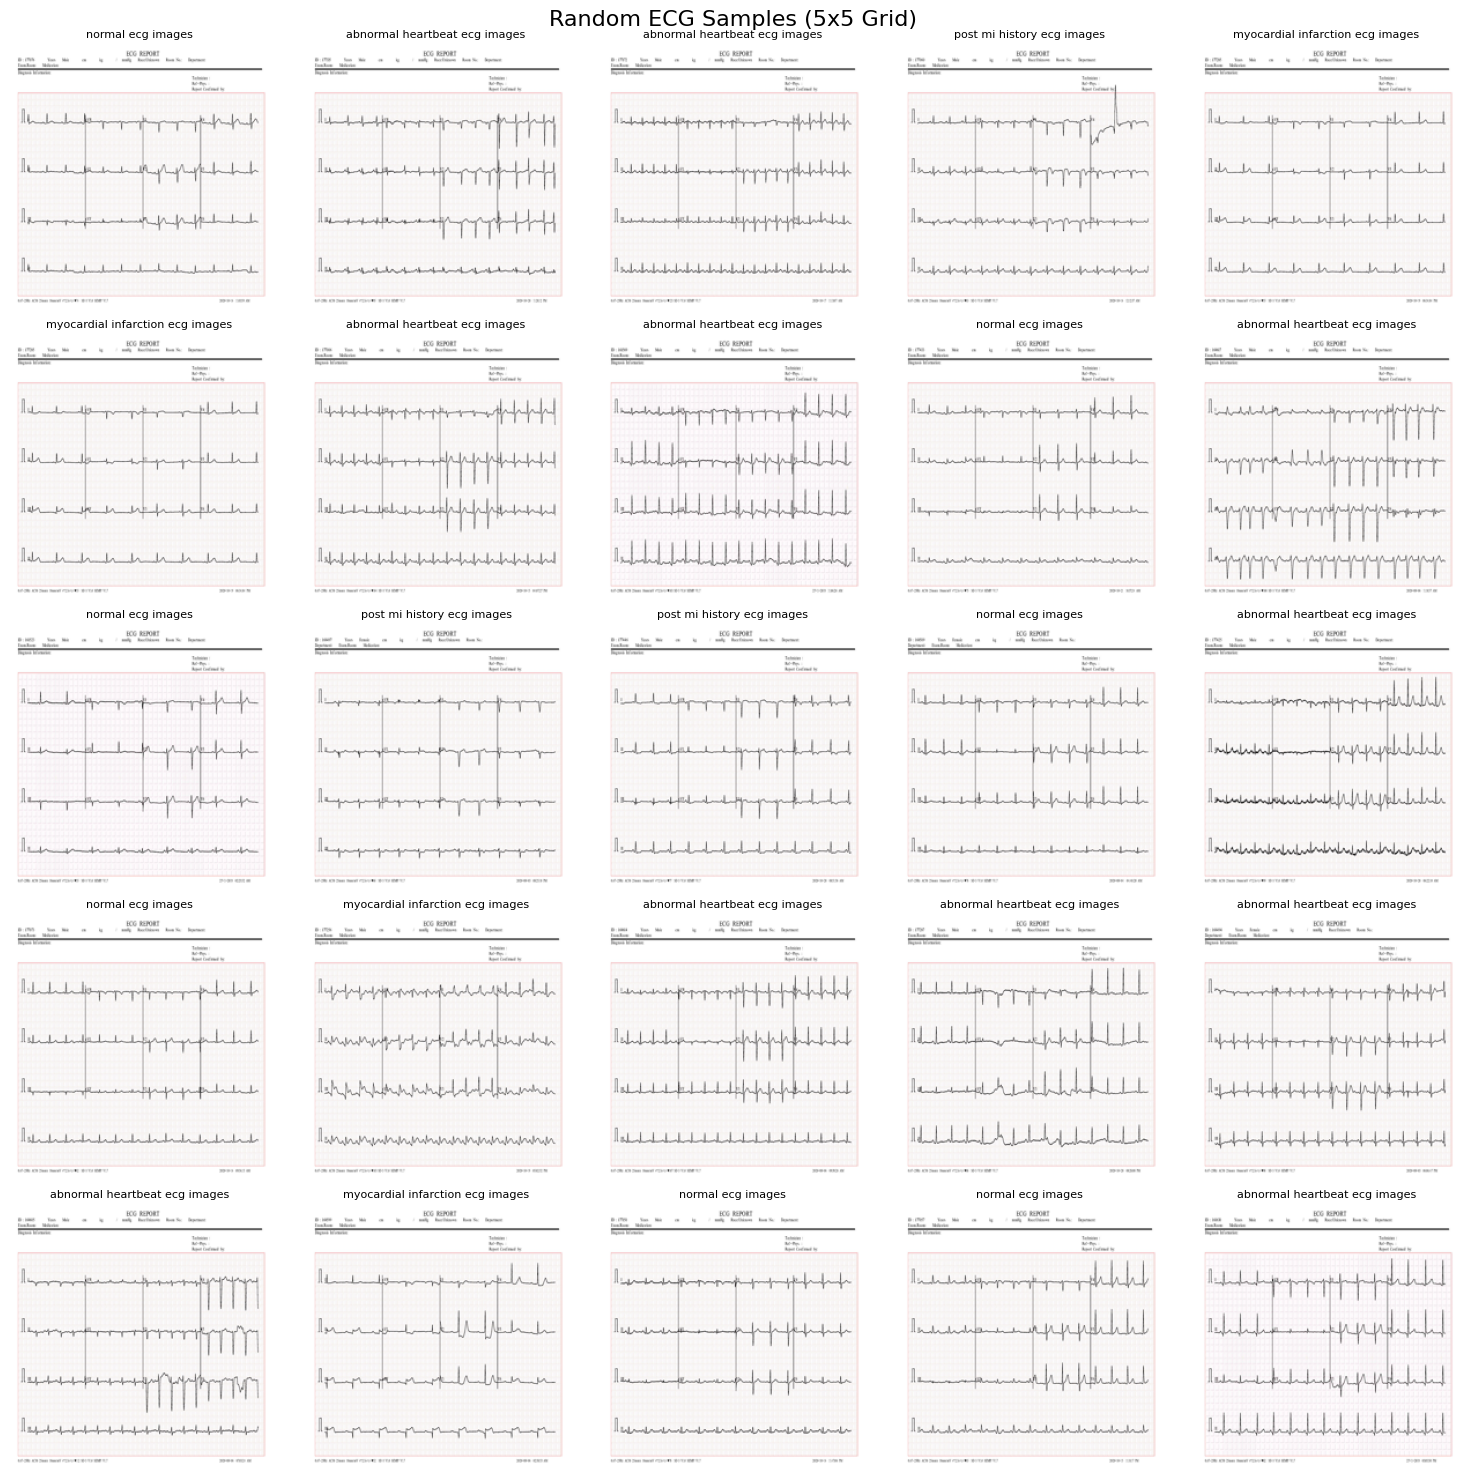

In [7]:
image_paths = []

for class_name in os.listdir(DATA_ROOT):
    class_dir = os.path.join(DATA_ROOT, class_name)

    if os.path.isdir(class_dir):
        for img_name in os.listdir(class_dir):
            if img_name.lower().endswith((".png", ".jpg", ".jpeg")):
                image_paths.append((os.path.join(class_dir, img_name), class_name))

# Randomly select 25 images
sample_images = random.sample(image_paths, 25)

# Plot 5x5 grid
fig, axes = plt.subplots(5, 5, figsize=(15, 15))

for ax, (img_path, label) in zip(axes.ravel(), sample_images):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((IMAGE_SIZE, IMAGE_SIZE))

    ax.imshow(img)
    ax.set_title(label.replace("_", " "), fontsize=8)
    ax.axis("off")

plt.suptitle("Random ECG Samples (5x5 Grid)", fontsize=16)
plt.tight_layout()
plt.show()

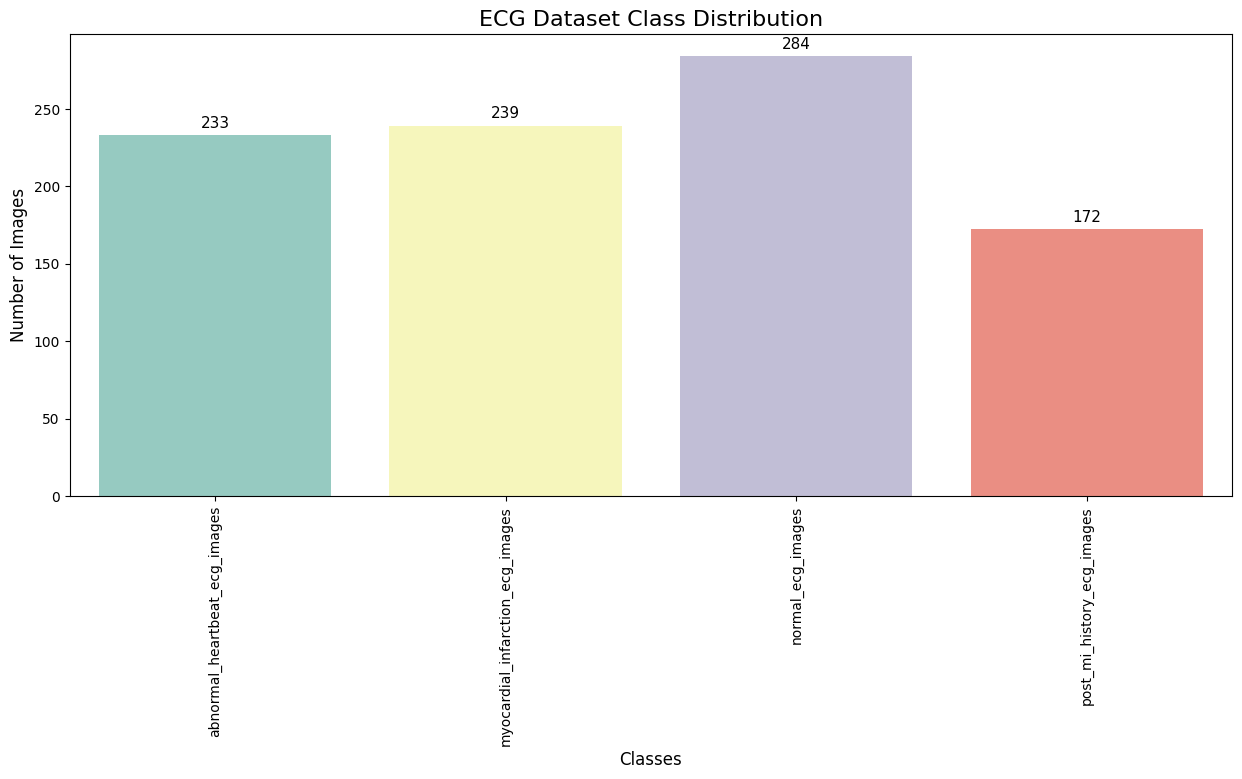

In [8]:
class_counts = {}

for class_name in os.listdir(DATA_ROOT):
    class_path = os.path.join(DATA_ROOT, class_name)

    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

df = pd.DataFrame({"Class": class_counts.keys(),"Count": class_counts.values()})

plt.figure(figsize=(15, 6))

sns.barplot(data=df,x="Class",y="Count",palette="Set3")

plt.title("ECG Dataset Class Distribution", fontsize=16)
plt.xlabel("Classes", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=90)

for index, value in enumerate(df["Count"]):
    plt.text(index, value + 5, str(value), ha='center', fontsize=11)

plt.show()


In [9]:
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

full_dataset = datasets.ImageFolder(root=DATA_ROOT, transform=None)

print(f"Classes : {full_dataset.classes}")
print(f"Total   : {len(full_dataset)} images")

Classes : ['abnormal_heartbeat_ecg_images', 'myocardial_infarction_ecg_images', 'normal_ecg_images', 'post_mi_history_ecg_images']
Total   : 928 images


In [10]:
labels = [label for _, label in full_dataset.samples]
indices = list(range(len(full_dataset)))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.20,
    stratify=labels,
    random_state=RANDOM_SEED,
)

temp_labels = [labels[i] for i in temp_idx]

valid_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=temp_labels,
    random_state=RANDOM_SEED,
)

print(f"Train : {len(train_idx)} | Valid : {len(valid_idx)} | Test : {len(test_idx)}")

Train : 742 | Valid : 93 | Test : 93


In [11]:
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


train_subset = TransformSubset(Subset(full_dataset, train_idx), train_transforms)
valid_subset = TransformSubset(Subset(full_dataset, valid_idx), val_test_transforms)
test_subset  = TransformSubset(Subset(full_dataset, test_idx), val_test_transforms)


train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

valid_loader = DataLoader(
    valid_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

test_loader = DataLoader(
    test_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

In [12]:
imgs, labels = next(iter(train_loader))

print(f"Images shape: {imgs.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Unique labels in batch: {labels.unique().tolist()}")

Images shape: torch.Size([4, 3, 224, 224])
Labels shape: torch.Size([4])
Unique labels in batch: [0, 1, 2]


In [13]:


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 4

class MultiScaleBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.branch1 = nn.Conv2d(in_channels, out_channels // 4, kernel_size=1)
        self.branch2 = nn.Conv2d(in_channels, out_channels // 4, kernel_size=3, padding=1)
        self.branch3 = nn.Conv2d(in_channels, out_channels // 4, kernel_size=5, padding=2)
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, out_channels // 4, kernel_size=1),
        )
        self.residual = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()
        self.bn = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(0.1)

    def forward(self, x):
        residual = self.residual(x)
        out = torch.cat([self.branch1(x), self.branch2(x), self.branch3(x), self.branch4(x)], dim=1)
        out = self.bn(out)
        out = F.relu(out)
        out = self.dropout(out)
        out = out + residual
        return F.relu(out)

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, in_channels, num_heads=8):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = in_channels // num_heads
        self.scale = self.head_dim ** -0.5
        self.query = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.key = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.value = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.out_conv = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        batch, channels, height, width = x.shape
        q = self.query(x).view(batch, self.num_heads, self.head_dim, height * width).permute(0, 1, 3, 2)
        k = self.key(x).view(batch, self.num_heads, self.head_dim, height * width)
        v = self.value(x).view(batch, self.num_heads, self.head_dim, height * width).permute(0, 1, 3, 2)
        attn = (q @ k) * self.scale
        attn = F.softmax(attn, dim=-1)
        attn = self.dropout(attn)
        out = (attn @ v).permute(0, 1, 3, 2).reshape(batch, channels, height, width)
        out = self.out_conv(out)
        return x + out

class SimCardioNet(nn.Module):
    def __init__(self, num_classes=4, ssl_proj_dim=128, dropout=0.4):
        super().__init__()
        self.initial = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )
        self.block1 = MultiScaleBlock(64, 256)
        self.block2 = MultiScaleBlock(256, 512)
        self.block3 = MultiScaleBlock(512, 1024)
        self.attention = MultiHeadSelfAttention(1024, num_heads=8)
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.global_max_pool = nn.AdaptiveMaxPool2d((1, 1))
        self.fusion = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.classifier = nn.Linear(1024, num_classes)
        self.projection_head = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, ssl_proj_dim),
        )

    def forward(self, x, ssl=False):
        x = self.initial(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.attention(x)
        avg_pool = self.global_avg_pool(x).view(x.size(0), -1)
        max_pool = self.global_max_pool(x).view(x.size(0), -1)
        x = torch.cat([avg_pool, max_pool], dim=1)
        x = self.fusion(x)
        if ssl:
            return F.normalize(self.projection_head(x), dim=1)
        return self.classifier(x)

model = SimCardioNet(num_classes=NUM_CLASSES).to(DEVICE)


summary(model, input_size=(3, 224, 224), batch_size=32, device=DEVICE.type)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [32, 64, 112, 112]           9,472
       BatchNorm2d-2         [32, 64, 112, 112]             128
              ReLU-3         [32, 64, 112, 112]               0
         MaxPool2d-4           [32, 64, 56, 56]               0
            Conv2d-5          [32, 256, 56, 56]          16,640
            Conv2d-6           [32, 64, 56, 56]           4,160
            Conv2d-7           [32, 64, 56, 56]          36,928
            Conv2d-8           [32, 64, 56, 56]         102,464
         MaxPool2d-9           [32, 64, 56, 56]               0
           Conv2d-10           [32, 64, 56, 56]           4,160
      BatchNorm2d-11          [32, 256, 56, 56]             512
        Dropout2d-12          [32, 256, 56, 56]               0
  MultiScaleBlock-13          [32, 256, 56, 56]               0
           Conv2d-14          [32, 512,

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [ ]:
from IPython.display import clear_output
from tabulate import tabulate
import torch

save_path = "best_ecg_model.pth"
best_val_loss = float("inf")
counter = 0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
epoch_results = []

print(f"Training on {DEVICE}\n")

for epoch in range(1, EPOCHS + 1):
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    train_bar = tqdm(train_loader, desc=f"Train Epoch {epoch}/{EPOCHS}", leave=False, unit="batch")
    for imgs, labels in train_bar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        t_loss += loss.item() * imgs.size(0)
        t_correct += (logits.argmax(1) == labels).sum().item()
        t_total += imgs.size(0)
        train_bar.set_postfix(loss=f"{loss.item():.4f}")
    train_loss = t_loss / t_total
    train_acc = t_correct / t_total * 100

    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    val_bar = tqdm(valid_loader, desc=f"Valid Epoch {epoch}/{EPOCHS}", leave=False, unit="batch")
    with torch.no_grad():
        for imgs, labels in val_bar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss = criterion(logits, labels)
            v_loss += loss.item() * imgs.size(0)
            v_correct += (logits.argmax(1) == labels).sum().item()
            v_total += imgs.size(0)
            val_bar.set_postfix(loss=f"{loss.item():.4f}")
    val_loss = v_loss / v_total
    val_acc = v_correct / v_total * 100

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    epoch_results.append([epoch, train_loss, train_acc, val_loss, val_acc])

    clear_output(wait=True)
    print(f"Training on {DEVICE}\n")
    print(tabulate(
        epoch_results,
        headers=["Epoch", "Train Loss", "Train Accuracy (%)", "Val Loss", "Val Accuracy (%)"],
        tablefmt="heavy_grid",
        floatfmt=".4f",
        numalign="center",
        stralign="center"
    ))
    print()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "val_loss": val_loss,
            "val_acc": val_acc,
        }, save_path)
        print(f"Saved best model at epoch {epoch}\n")
    else:
        counter += 1
        print(f"No improvement ({counter}/{patience})\n")
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

print("\n=== Training Complete ===\n")

Training on cuda



Train Epoch 1/50:   0%|          | 0/186 [00:00<?, ?batch/s]

In [ ]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ECG Classifier — Training History", fontsize=15, fontweight="bold", y=1.02)

# ── Loss ─────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs, history["train_loss"], "o-",  color="#4C72B0", linewidth=2, markersize=5, label="Train Loss")
ax.plot(epochs, history["val_loss"],   "s--", color="#DD8452", linewidth=2, markersize=5, label="Val Loss")
ax.set_title("Loss", fontsize=13, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

# ── Accuracy ──────────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(epochs, history["train_acc"], "o-",  color="#4C72B0", linewidth=2, markersize=5, label="Train Acc")
ax.plot(epochs, history["val_acc"],   "s--", color="#DD8452", linewidth=2, markersize=5, label="Val Acc")
ax.set_title("Accuracy", fontsize=13, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 100)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
plt.show()